# Example: Stress-Testing the Rebalancing Engine

In this example, we stress-test the **Cobb-Douglas rebalancing engine** from the previous notebook across 5,000 independent hybrid-SIM forward paths and compare its distributional behavior against three static baselines: the Session 1 min-var portfolio (buy-and-hold), an equal-weight buy-and-hold, the market (SPY surrogate), and a risk-free baseline. We build a tail-risk scorecard with VaR, CVaR, drawdown quantiles, and NPV metrics, then visualize the full wealth distribution to see *where* the engine wins and loses relative to static allocation.

> **By the end of this example, you will be able to:**
> * __Run a 5,000-path engine stress test:__ Drive the Cobb-Douglas rebalancing engine through a single large hybrid-SIM scenario using [`backtest_engine(...)`](../../code/docs/build/session2.html), alongside buy-and-hold benchmarks. Per-path final wealth, drawdown, and Sharpe arrays populate the distributional analysis downstream.
> * __Build a tail-risk scorecard:__ Translate per-path arrays into VaR, CVaR, median drawdown, and NPV-scaled metrics that answer "what happens to my capital on the worst 5% of paths?" The NPV view expresses the worst-case outcome in today's dollars relative to the risk-free baseline.
> * __Visualize the wealth distribution:__ Plot terminal-wealth, drawdown, and NPV histograms across strategies, plus a corridor chart highlighting the worst 5% of min-var trajectories. These visuals expose where the engine's adaptivity helps (tighter drawdowns) and where it hurts (fatter upside tails).

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

Load the user-selected universe and SIM calibration from the Session 1 `minvar-allocation.jld2` artifact, the full SIM parameter estimates from `sim-parameter-estimates.jld2`, the HMM surrogate models, and the current-price snapshot. The `let...end` block below populates `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `allocation_weights::Vector{Float64}` (S1 min-var), `g_f::Float64`, `B₀::Float64`, `N::Int`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}` (allocator-adapter form), `start_prices::Dict{String,Float64}`, plus the `market_model`, `portfolio`, and `calib` objects used by `generate_hybrid_scenario`.

In [2]:
let
    # --- Step 1: Load S1 artifacts (same universe + weights used in Example 1) ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    global my_tickers         = minvar["my_tickers"]::Vector{String};
    global sim_estimates      = minvar["sim_estimates"];
    global allocation_weights = Float64.(minvar["allocation_weights"]);
    global g_f                = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : (haskey(minvar, "r_f") ? Float64(minvar["r_f"]) : 0.045);

    # --- Step 2: Stress-test constants ---
    global B₀ = 10_000.0;
    global N  = length(my_tickers);

    # --- Step 3: Build the allocator-adapter sim_params Dict ---
    global sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 4: Load surrogates, calibration, and start prices ---
    global market_model = MyMarketSurrogateModel();
    global portfolio    = MyPortfolioSurrogateModel();
    global calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));

    snap        = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    global start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    println("Loaded S1 universe: $(N) tickers = $(my_tickers)")
    println("  S1 min-var weights: $(round.(allocation_weights .* 100, digits=2))%")
    println("  g_f: $(round(g_f*100, digits=2))% / year (continuous)")
end;

Loaded S1 universe: 10 tickers = ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]


  S1 min-var weights: [3.12, 12.08, 7.94, 33.7, -0.0, 43.17, -0.0, -0.0, -0.0, -0.0]%
  g_f: 4.5% / year (continuous)


### Implementation — Static Cobb-Douglas Baseline
The library's `backtest_engine` runs a *dynamic* rebalancing engine that recomputes preference weights $\gamma_i$ every trading day from the evolving $\lambda_t$ signal. To attribute how much of the engine's edge comes from dynamic reallocation versus the Cobb-Douglas utility structure itself, we need a *static* baseline: fit $\gamma$ once at the first trading day, allocate, and hold the resulting shares unchanged through the active window.

We define a local helper `backtest_static_cd(scenario, tickers, sim_params, lambda_mode; ...)` that runs this static Cobb-Douglas strategy across every path in a `MyBacktestScenario`. Two λ-fitting modes are supported:

* __`:warmup_avg`__ — use the mean of the EMA-crossover $\lambda$ signal over the post-EMA-stabilization warmup window (days `N_long+1` through `offset`). This is a historical-fit: "what did sentiment look like on average over the last N days of the calibration window."
* __`:neutral`__ — set $\lambda = 0$ exactly. The simplest baseline: Cobb-Douglas without any sentiment overlay.

Both modes compute $\gamma$ from the SIM parameters using `compute_preference_weights(sim_params, tickers, gm_buyin, λ_static)` where `gm_buyin` is the smoothed market growth rate at the buy-in day, then solve `allocate_cobb_douglas` once at the buy-in price. The resulting `shares` and `cash` are held fixed from day `offset+1` through day `n_steps`, with daily wealth marked to market. The function returns a `MyBacktestResult` with the same shape as `backtest_engine` so the downstream scorecard code handles it uniformly.

In [3]:
"""
    backtest_static_cd(scenario::MyBacktestScenario, tickers, sim_params, lambda_mode; ...) -> MyBacktestResult

Run a **static** Cobb-Douglas buy-and-hold strategy across every path in a scenario.

Per path:
1. Determine λ_static according to `lambda_mode`:
   - `:neutral`    → 0.0
   - `:warmup_avg` → mean of compute_lambda(ema_short, ema_long) over days `N_long+1 : offset`
2. Compute preference weights γ using the SIM-based formula with this static λ and
   the smoothed market growth rate gm_ema at the buy-in day.
3. Solve allocate_cobb_douglas once at the buy-in day's prices.
4. Hold the resulting shares + cash through the active window, marking to market.

### Arguments
- `scenario::MyBacktestScenario`: Pre-generated scenario with `n_paths × n_steps × N` price tensor.
- `tickers::Vector{String}`: Asset ticker list (length `N`).
- `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: Allocator-adapter SIM params, one entry per ticker.
- `lambda_mode::Symbol`: Either `:neutral` or `:warmup_avg`.

### Keywords
- `B₀::Float64 = 10_000.0`: Initial budget.
- `offset::Int = 84`: Warmup window length in days.
- `N_short::Int = 21`, `N_long::Int = 63`, `N_growth::Int = 10`: EMA windows.
- `GAIN::Float64 = 10.0`: λ gain used by compute_lambda.
- `epsilon::Float64 = 0.1`: ε floor for non-preferred assets.

### Returns
- `MyBacktestResult` with per-path `final_wealth`, `max_drawdowns`, `sharpe_ratios`.
"""
function backtest_static_cd(scenario::MyBacktestScenario,
    tickers::Vector{String},
    sim_params::Dict{String,Tuple{Float64,Float64,Float64}},
    lambda_mode::Symbol;
    B₀::Float64 = 10_000.0, offset::Int = 84,
    N_short::Int = 21, N_long::Int = 63, N_growth::Int = 10,
    GAIN::Float64 = 10.0, epsilon::Float64 = 0.1)::MyBacktestResult

    Δt = 1.0 / 252.0;
    n_paths   = scenario.n_paths;
    n_steps   = scenario.n_steps;
    N         = length(tickers);
    n_trading = n_steps - offset;

    final_wealth  = zeros(n_paths);
    max_drawdowns = zeros(n_paths);
    sharpe_ratios = zeros(n_paths);

    for p ∈ 1:n_paths

        # --- Step 1: Extract per-path market series ---
        mkt    = scenario.market_paths[p, :];
        gm_raw = compute_market_growth(mkt; Δt = Δt);
        gm_e   = compute_ema(gm_raw; window = N_growth);

        # --- Step 2: Fit static λ according to mode ---
        λ_static = if lambda_mode == :neutral
            0.0
        elseif lambda_mode == :warmup_avg
            ema_s = compute_ema(mkt; window = N_short);
            ema_l = compute_ema(mkt; window = N_long);
            λ_raw = compute_lambda(ema_s, ema_l; G = GAIN);
            # mean over post-EMA-stabilization warmup
            mean(λ_raw[(N_long + 1):offset])
        else
            error("Unknown lambda_mode: $(lambda_mode). Use :neutral or :warmup_avg.")
        end

        # --- Step 3: Compute γ at the buy-in day using static λ ---
        buyin_day = offset + 1;
        gm_t = gm_e[min(buyin_day, length(gm_e))];
        γ = compute_preference_weights(sim_params, tickers, gm_t, λ_static);

        # --- Step 4: Allocate once at buy-in prices ---
        prices_buyin = [scenario.price_paths[p, buyin_day, k] for k ∈ 1:N];
        problem = build(MyCobbDouglasChoiceProblem, (
            gamma = γ, prices = prices_buyin, B = B₀, epsilon = epsilon
        ));
        (shares, cash) = allocate_cobb_douglas(problem);

        # --- Step 5: Mark to market on the active window, holding shares + cash fixed ---
        wealth = zeros(n_trading + 1);
        for d ∈ 0:n_trading
            day = buyin_day + d;
            if day > n_steps
                day = n_steps;
            end
            wealth[d + 1] = cash + sum(shares[k] * scenario.price_paths[p, day, k] for k ∈ 1:N);
        end

        # --- Step 6: Per-path metrics ---
        final_wealth[p] = wealth[end];
        returns  = diff(wealth) ./ wealth[1:end-1];
        peak     = accumulate(max, wealth);
        max_drawdowns[p] = maximum((peak .- wealth) ./ peak);
        vol      = std(returns) * sqrt(252);
        mean_ret = (wealth[end] / wealth[1] - 1.0);
        sharpe_ratios[p] = vol > 1e-6 ? mean_ret / vol : 0.0;
    end

    result = MyBacktestResult();
    result.scenario_label = scenario.label;
    result.strategy_label = "Static CD ($(lambda_mode) λ)";
    result.final_wealth   = final_wealth;
    result.max_drawdowns  = max_drawdowns;
    result.sharpe_ratios  = sharpe_ratios;
    return result;
end;

___
## Task 1: Generate the 5,000-Path Scenario and Run All Strategies
We generate one large hybrid-SIM forward scenario (5,000 paths × 336 days) and run five strategies across it: the Cobb-Douglas rebalancing engine, the Session 1 min-var portfolio (buy-and-hold), an equal-weight buy-and-hold, a market (SPY surrogate) buy-and-hold, and a deterministic risk-free baseline. All strategies share the same 84-day warmup and 252-day active window, so every per-path metric is comparable head-to-head.

> __What should you see?__
>
> The scenario shape should be `(5000, 336)` for market paths and `(5000, 336, 10)` for ticker prices. The engine takes the longest to run because it iterates the Cobb-Douglas allocation daily per path; the buy-and-hold baselines are O(N) per path. Median final $W/W_0$ should be noticeably larger than 1.0 for the engine and near 1.0 for min-var (reflecting the single forward-year horizon).

The `let...end` block below calls [`generate_hybrid_scenario(...)`](../../code/docs/build/session1.html) with `n_paths=5000, seed=2026`, then runs [`backtest_engine(...)`](../../code/docs/build/session2.html) for the Cobb-Douglas engine and [`backtest_buyhold(...)`](../../code/docs/build/session2.html) / [`backtest_buyhold_market(...)`](../../code/docs/build/session2.html) for the baselines. Results escape as `scenario::MyBacktestScenario`, five `MyBacktestResult` objects (`result_eng`, `result_mv`, `result_eq`, `result_mkt`, `result_rf`), and the scalars `n_paths::Int` and `n_steps::Int`.

In [4]:
scenario, result_eng, result_scd_warmup, result_scd_neutral, result_mv, result_eq, result_mkt, result_rf, n_paths, n_steps = let

    # --- Step 1: Stress-test configuration ---
    n_paths = 5_000;
    n_steps = 336;                 # 84 warmup + 252 active (matches Example 1)
    offset  = 84;
    Δt      = 1.0 / 252.0;
    seed    = 2026;

    # --- Step 2: Generate one large hybrid-SIM scenario ---
    println("Generating $(n_paths)-path hybrid-SIM scenario ($(n_steps) days, seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths      = n_paths,
        n_steps      = n_steps,
        Δt           = Δt,
        start_prices = start_prices,
        label        = "S2 Stress-Test ($(n_paths)p × $(n_steps)d)",
        seed         = seed);
    println("  price_paths:  $(size(scen.price_paths))")
    println("  market_paths: $(size(scen.market_paths))")

    # --- Step 3: Cobb-Douglas rebalancing engine across all paths ---
    rules_params = (max_drawdown = 0.15, max_turnover = 0.50);
    println("\nRunning Cobb-Douglas engine across $(n_paths) paths...")
    r_eng = backtest_engine(scen, my_tickers, sim_params, rules_params;
        B₀ = B₀, offset = offset);
    r_eng.strategy_label = "Cobb-Douglas Engine (DD≤15%, τ≤50%)";

    # --- Step 3b: Static Cobb-Douglas baselines (two λ flavors) ---
    println("Running Static CD (warmup-avg λ) across $(n_paths) paths...")
    r_scd_w = backtest_static_cd(scen, my_tickers, sim_params, :warmup_avg;
        B₀ = B₀, offset = offset);

    println("Running Static CD (neutral λ=0) across $(n_paths) paths...")
    r_scd_n = backtest_static_cd(scen, my_tickers, sim_params, :neutral;
        B₀ = B₀, offset = offset);

    # --- Step 4: Static baselines — S1 min-var, equal-weight, market ---
    eqw = fill(1.0 / N, N);
    r_mv  = backtest_buyhold(scen, my_tickers; B₀ = B₀, offset = offset, weights = allocation_weights);
    r_mv.strategy_label = "S1 Min-Var (buy-and-hold)";
    r_eq  = backtest_buyhold(scen, my_tickers; B₀ = B₀, offset = offset, weights = eqw);
    r_eq.strategy_label = "Equal-Weight (buy-and-hold)";
    r_mkt = backtest_buyhold_market(scen; B₀ = B₀, offset = offset);
    r_mkt.strategy_label = "Market (SPY surrogate)";

    # --- Step 5: Risk-free deterministic baseline ---
    # Every path ends at B₀·exp(g_f · T_active), so drawdowns are identically zero
    # and NPV is identically zero by construction (same g_f used to compound and discount).
    T_active = (n_steps - offset) / 252;
    rf_terminal = B₀ * exp(g_f * T_active);
    r_rf = MyBacktestResult();
    r_rf.scenario_label = scen.label;
    r_rf.strategy_label = "Risk-Free $(round(g_f*100, digits=1))%";
    r_rf.final_wealth   = fill(rf_terminal, n_paths);
    r_rf.max_drawdowns  = zeros(n_paths);
    r_rf.sharpe_ratios  = zeros(n_paths);

    println("\nAll seven strategies run. Median final W/W₀ by strategy:")
    for r ∈ (r_eng, r_scd_w, r_scd_n, r_mv, r_eq, r_mkt, r_rf)
        med = median(r.final_wealth) / B₀;
        println("  ", rpad(r.strategy_label, 42), " W/W₀ = ", round(med, digits=3))
    end

    scen, r_eng, r_scd_w, r_scd_n, r_mv, r_eq, r_mkt, r_rf, n_paths, n_steps
end;

Generating 5000-path hybrid-SIM scenario (336 days, seed=2026)...
  price_paths:  (5000, 336, 10)


  market_paths: (5000, 336)

Running Cobb-Douglas engine across 5000 paths...
Running Static CD (warmup-avg λ) across 5000 paths...


Running Static CD (neutral λ=0) across 5000 paths...



All seven strategies run. Median final W/W₀ by strategy:


  Cobb-Douglas Engine (DD≤15%, τ≤50%)       

 W/W₀ = 1.731
  Static CD (warmup_avg λ)                   W/W₀ = 1.14
  Static CD (neutral λ)                      W/W₀ = 1.139
  S1 Min-Var (buy-and-hold)                  W/W₀ = 1.146
  Equal-Weight (buy-and-hold)                W/W₀ = 1.208
  Market (SPY surrogate)                     W/W₀ = 1.119
  Risk-Free 4.5%                             W/W₀ = 1.046


___
## Task 2: Tail-Risk Scorecard — VaR, CVaR, Drawdown, and NPV
The per-path arrays from Task 1 let us compute distributional tail metrics that a single-path scorecard cannot. We build one scorecard row per strategy with:

* __Median terminal wealth__ and __VaR₅__ (5th percentile of terminal wealth)
* __CVaR₅__ (mean of the worst 5% of terminal wealth) with an analytical standard error
* __Median and P95 maximum drawdown__
* __Median Sharpe ratio__
* __NPV metrics__ — median NPV in dollars, NPV as % of $B_0$, CVaR₅ of NPV, and the probability that a path underperforms the risk-free baseline

The NPV columns translate the terminal wealth into today's dollars using the discount factor $e^{-g_f \cdot T}$ applied uniformly across strategies. Because the risk-free portfolio is compounded and discounted at the same $g_f$, every risk-free path has $\text{NPV} \equiv 0$ by construction — it's the zero reference for the other strategies.

The `let...end` block below defines a local `tail_metrics` helper, builds the scorecard `DataFrame`, and displays it via the canonical `pretty_table` kwargs. The final DataFrame escapes as `scorecard::DataFrame`.

In [5]:
scorecard = let

    # --- Step 1: Discount factor for the NPV translation ---
    T_active = (n_steps - 84) / 252;
    discount = exp(-g_f * T_active);
    npv_array(r::MyBacktestResult) = r.final_wealth .* discount .- B₀;

    # --- Step 2: Per-strategy tail metrics helper ---
    function tail_metrics(r::MyBacktestResult, B0::Float64)
        wealth = r.final_wealth;
        npv    = npv_array(r);
        n      = length(wealth);
        n_tail = max(1, floor(Int, 0.05 * n));

        sorted_wealth = sort(wealth);
        wealth_tail   = sorted_wealth[1:n_tail];
        cvar5         = mean(wealth_tail);
        cvar5_se      = (length(wealth_tail) > 1) ? std(wealth_tail) / sqrt(n_tail) : 0.0;

        sorted_npv   = sort(npv);
        npv_tail     = sorted_npv[1:n_tail];
        cvar5_npv    = mean(npv_tail);

        return (
            Portfolio  = r.strategy_label,
            Median_W   = round(median(wealth),                digits=0),
            VaR_5      = round(quantile(wealth, 0.05),        digits=0),
            CVaR_5     = round(cvar5,                         digits=0),
            CVaR_5_SE  = round(cvar5_se,                      digits=0),
            Med_DD_pct = round(median(r.max_drawdowns) * 100, digits=2),
            P95_DD_pct = round(quantile(r.max_drawdowns, 0.95) * 100, digits=2),
            Med_Sharpe = round(median(r.sharpe_ratios),       digits=3),
            Med_NPV    = round(median(npv),                   digits=0),
            NPV_scaled = round(median(npv) / B0 * 100,        digits=2),
            CVaR5_NPV  = round(cvar5_npv,                     digits=0),
            P_NPV_neg  = round(mean(npv .< 0) * 100,          digits=1),
        );
    end

    # --- Step 3: Build rows and display ---
    rows = [
        tail_metrics(result_eng,         B₀),
        tail_metrics(result_scd_warmup,  B₀),
        tail_metrics(result_scd_neutral, B₀),
        tail_metrics(result_mv,          B₀),
        tail_metrics(result_eq,          B₀),
        tail_metrics(result_mkt,         B₀),
        tail_metrics(result_rf,          B₀),
    ];
    df = DataFrame(rows);

    println("Tail-risk scorecard over $(n_paths) paths, $((n_steps - 84))-day active horizon (T = $(round(T_active, digits=3)) yr)")
    println("Discount factor e^(-g_f·T) = $(round(discount, digits=5))")
    println()
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Step 4: Convergence sanity check on CVaR standard errors ---
    n_tail = floor(Int, 0.05 * n_paths);
    println()
    println("CVaR sample size: $(n_tail) paths in the 5% tail.")
    println("Standard-error / point-estimate ratios:")
    for row ∈ eachrow(df)
        if row.CVaR_5 > 0 && row.CVaR_5_SE > 0
            ratio = row.CVaR_5_SE / abs(row.CVaR_5);
            println("  $(rpad(row.Portfolio, 42)) SE / |CVaR| = $(round(ratio*100, digits=2))%")
        else
            println("  $(rpad(row.Portfolio, 42)) deterministic — SE = 0 by construction")
        end
    end
    println("Rule of thumb: if any non-deterministic SE/|CVaR| ratio exceeds ~1%, increase n_paths.")

    df
end;

Tail-risk scorecard over 5000 paths, 252-day active horizon (T = 1.0 yr)


Discount factor e^(-g_f·T) = 0.956

 ------------------------------------- ---------- --------- --------- ----------- ------------ ------------ ------------ --------- ------------ ----------- -----------
                            Portfolio   Median_W     VaR_5    CVaR_5   CVaR_5_SE   Med_DD_pct   P95_DD_pct   Med_Sharpe   Med_NPV   NPV_scaled   CVaR5_NPV   P_NPV_neg 
                               String    Float64   Float64   Float64     Float64      Float64      Float64      Float64   Float64      Float64     Float64     Float64 
 ------------------------------------- ---------- --------- --------- ----------- ------------ ------------ ------------ --------- ------------ ----------- -----------
  Cobb-Douglas Engine (DD≤15%, τ≤50%)    17311.0   12409.0   10730.0        78.0         8.94        15.03        3.356    6549.0        65.49       258.0         2.0
             Static CD (warmup_avg λ)    11398.0    8962.0    7855.0        58.0        17.97        37.44        0.929     8


CVaR sample size: 250 paths in the 5% tail.
Standard-error / point-estimate ratios:
  Cobb-Douglas Engine (DD≤15%, τ≤50%)        SE / |CVaR| = 0.73%
  Static CD (warmup_avg λ)                   SE / |CVaR| = 0.74%


  Static CD (neutral λ)                      SE / |CVaR| = 0.74%
  S1 Min-Var (buy-and-hold)                  SE / |CVaR| = 0.41%
  Equal-Weight (buy-and-hold)                SE / |CVaR| = 0.59%
  Market (SPY surrogate)                     SE / |CVaR| = 0.51%
  Risk-Free 4.5%                             deterministic — SE = 0 by construction
Rule of thumb: if any non-deterministic SE/|CVaR| ratio exceeds ~1%, increase n_paths.


___
## Task 3: Visualize the Wealth Distribution and Tail Trajectories
Two complementary views of the same 5,000-path ensemble. First, three histograms overlay terminal wealth $W/W_0$, maximum drawdown, and NPV across the Cobb-Douglas engine, S1 min-var, and equal-weight strategies, with vertical markers for the risk-free break-even point and the deterministic risk-free terminal wealth. Then a corridor chart recomputes the min-var wealth trajectories for all 5,000 paths, draws the P5–P95 corridor in gray, and highlights the worst 5% of paths in red — so you can see *when* in the active window the tail paths drift away from the median.

> __What should you see?__
>
> The engine's terminal-wealth histogram should sit meaningfully to the right of the static baselines because adaptivity pays off in the average regime, but it should also have a wider right tail — that's the conviction-in-the-top-asset effect amplifying upside. The drawdown histogram should be tightest for the engine (because the 15% DD trigger actively clips tail drawdowns) and widest for equal-weight (no capital protection). On the min-var corridor chart, the red worst-5% paths should fan away from the P5 band well before the end of the horizon, foreshadowing the final-wealth tail.

The two `let...end` blocks below build `p_histograms::Plots.Plot` (3-panel histogram figure) and `p_corridor::Plots.Plot` (min-var wealth corridor). Neither escapes additional globals.

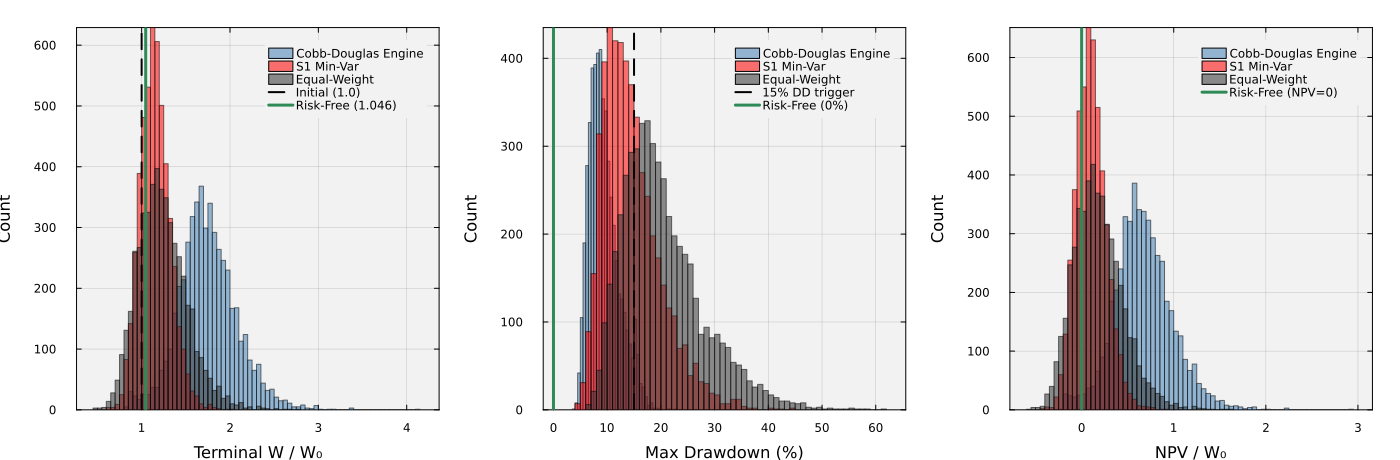

In [6]:
let
    T_active    = (n_steps - 84) / 252;
    discount    = exp(-g_f * T_active);
    rf_multiple = result_rf.final_wealth[1] / B₀;
    IW = B₀;

    # --- Per-path NPV arrays for the three risky strategies ---
    npv_eng = result_eng.final_wealth .* discount .- B₀;
    npv_mv  = result_mv.final_wealth  .* discount .- B₀;
    npv_eq  = result_eq.final_wealth  .* discount .- B₀;

    # --- Panel 1: terminal wealth / B₀ overlay ---
    p1 = histogram(result_eng.final_wealth ./ IW, bins=60, alpha=0.55, color=:steelblue,
        label="Cobb-Douglas Engine", xlabel="Terminal W / W₀", ylabel="Count",
        fontsize=18);
    histogram!(p1, result_mv.final_wealth ./ IW, bins=60, alpha=0.55, color=:red,
        label="S1 Min-Var");
    histogram!(p1, result_eq.final_wealth ./ IW, bins=60, alpha=0.55, color=:gray20,
        label="Equal-Weight");
    vline!(p1, [1.0], lw=2, ls=:dash, c=:black, label="Initial (1.0)");
    vline!(p1, [rf_multiple], lw=3, c=:seagreen,
        label="Risk-Free ($(round(rf_multiple, digits=3)))");
    plot!(p1, bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright);

    # --- Panel 2: max drawdown overlay ---
    p2 = histogram(result_eng.max_drawdowns .* 100, bins=60, alpha=0.55, color=:steelblue,
        label="Cobb-Douglas Engine", xlabel="Max Drawdown (%)", ylabel="Count",
        fontsize=18);
    histogram!(p2, result_mv.max_drawdowns .* 100, bins=60, alpha=0.55, color=:red,
        label="S1 Min-Var");
    histogram!(p2, result_eq.max_drawdowns .* 100, bins=60, alpha=0.55, color=:gray20,
        label="Equal-Weight");
    vline!(p2, [15.0], lw=2, ls=:dash, c=:black, label="15% DD trigger");
    vline!(p2, [0.0], lw=3, c=:seagreen, label="Risk-Free (0%)");
    plot!(p2, bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright);

    # --- Panel 3: portfolio NPV overlay (scaled by B₀) ---
    p3 = histogram(npv_eng ./ IW, bins=60, alpha=0.55, color=:steelblue,
        label="Cobb-Douglas Engine", xlabel="NPV / W₀", ylabel="Count",
        fontsize=18);
    histogram!(p3, npv_mv ./ IW, bins=60, alpha=0.55, color=:red, label="S1 Min-Var");
    histogram!(p3, npv_eq ./ IW, bins=60, alpha=0.55, color=:gray20, label="Equal-Weight");
    vline!(p3, [0.0], lw=3, c=:seagreen, label="Risk-Free (NPV=0)");
    plot!(p3, bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright);

    plot(p1, p2, p3, layout=(1, 3), size=(1400, 460), margin=5Plots.mm)
end

The `let...end` block below recomputes the full per-path S1 min-var wealth trajectories (5,000 × 253 days of active-window wealth) so we can draw the P5–P95 corridor plus highlight the worst 5% of paths in red against the median trajectory.

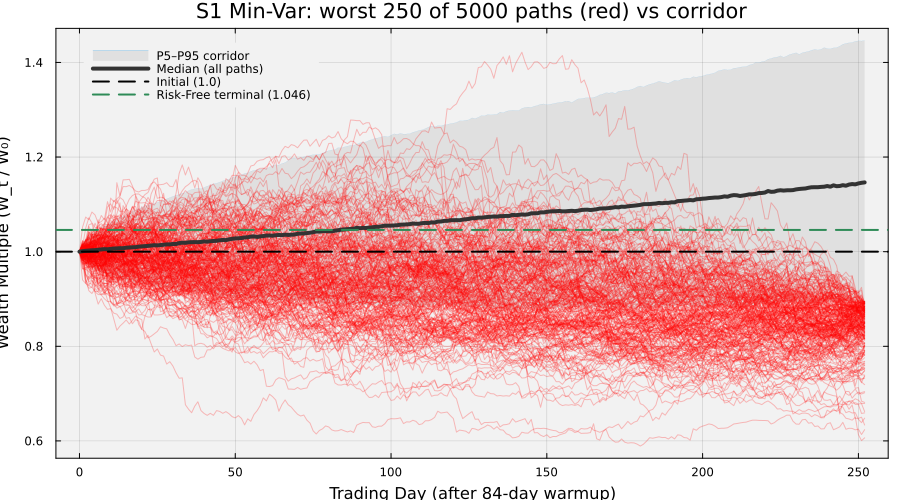

In [7]:
let
    # --- Step 1: Worst 5% of paths for the S1 min-var portfolio ---
    offset = 84;
    n_active = n_steps - offset;
    n_tail = max(1, floor(Int, 0.05 * n_paths));
    worst_idx = partialsortperm(result_mv.final_wealth, 1:n_tail);
    IW = B₀;
    rf_multiple = result_rf.final_wealth[1] / B₀;

    # --- Step 2: Recompute min-var wealth trajectories for ALL paths on the active window ---
    K_loc = length(my_tickers);
    wealth_all = zeros(n_active + 1, n_paths);
    for p ∈ 1:n_paths
        p_start = [scenario.price_paths[p, offset, k] for k ∈ 1:K_loc];
        shares  = B₀ .* allocation_weights ./ p_start;
        for d ∈ 0:n_active
            day = offset + d;
            wealth_all[d+1, p] = sum(shares[k] * scenario.price_paths[p, day, k] for k ∈ 1:K_loc);
        end
    end

    # --- Step 3: Corridor statistics across paths ---
    median_traj = [median(wealth_all[t, :]) for t ∈ 1:(n_active + 1)];
    p05_traj    = [quantile(wealth_all[t, :], 0.05) for t ∈ 1:(n_active + 1)];
    p95_traj    = [quantile(wealth_all[t, :], 0.95) for t ∈ 1:(n_active + 1)];

    days = 0:n_active;
    p = plot(days, p95_traj ./ IW,
        fillrange = p05_traj ./ IW, fillalpha = 0.20, fillcolor = :gray60,
        lw = 0, label = "P5–P95 corridor",
        xlabel = "Trading Day (after 84-day warmup)",
        ylabel = "Wealth Multiple (W_t / W₀)",
        fontsize = 18,
        size = (900, 500));
    for idx ∈ worst_idx
        plot!(p, days, wealth_all[:, idx] ./ IW,
            lw = 1, c = :red, alpha = 0.25, label = "");
    end
    plot!(p, days, median_traj ./ IW, lw = 4, c = :gray20, label = "Median (all paths)");
    hline!(p, [1.0], lw = 2, ls = :dash, c = :black, label = "Initial (1.0)");
    hline!(p, [rf_multiple], lw = 2, ls = :dash, c = :seagreen,
        label = "Risk-Free terminal ($(round(rf_multiple, digits=3)))");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);
    title!(p, "S1 Min-Var: worst $(n_tail) of $(n_paths) paths (red) vs corridor")
    display(p)
end

___
### Hand-off — saving the stress-test arrays for downstream sessions
We save the five per-path arrays (final wealth, max drawdowns, Sharpe ratios) and the NPV arrays for the three risky strategies, so Sessions 3 and 4 can consume them without re-running the 5,000-path backtest.

In [8]:
let
    T_active = (n_steps - 84) / 252;
    discount = exp(-g_f * T_active);

    # --- Step 1: Per-path summary stats from the underlying market path ---
    # These are the inputs the downstream StaticVsAdaptive notebook needs for
    # regime-conditional analysis, so we snapshot them here rather than
    # regenerating the 5,000-path scenario.
    market_terminal = [scenario.market_paths[p, end] for p ∈ 1:n_paths];
    market_start    = [scenario.market_paths[p, 84 + 1] for p ∈ 1:n_paths];  # buy-in day
    market_return   = (market_terminal ./ market_start) .- 1.0;               # simple return over active window

    save_path = joinpath(_PATH_TO_DATA, "stress-test-engine.jld2");
    save_results(save_path, Dict(
        "n_paths"             => n_paths,
        "n_steps"             => n_steps,
        "offset"              => 84,
        "g_f"                 => g_f,
        "r_f"                 => g_f,                 # backward-compatible alias
        "B₀"                  => B₀,
        "discount"            => discount,
        "my_tickers"          => my_tickers,
        "allocation_weights"  => allocation_weights,
        # Per-path market stats (for regime-conditional analysis)
        "market_terminal"     => market_terminal,
        "market_start"        => market_start,
        "market_return"       => market_return,
        # Engine
        "eng_final_wealth"    => result_eng.final_wealth,
        "eng_max_drawdowns"   => result_eng.max_drawdowns,
        "eng_sharpe_ratios"   => result_eng.sharpe_ratios,
        "eng_npv"             => result_eng.final_wealth .* discount .- B₀,
        # Static Cobb-Douglas, warmup-avg λ
        "scd_w_final_wealth"  => result_scd_warmup.final_wealth,
        "scd_w_max_drawdowns" => result_scd_warmup.max_drawdowns,
        "scd_w_sharpe_ratios" => result_scd_warmup.sharpe_ratios,
        "scd_w_npv"           => result_scd_warmup.final_wealth .* discount .- B₀,
        # Static Cobb-Douglas, neutral λ=0
        "scd_n_final_wealth"  => result_scd_neutral.final_wealth,
        "scd_n_max_drawdowns" => result_scd_neutral.max_drawdowns,
        "scd_n_sharpe_ratios" => result_scd_neutral.sharpe_ratios,
        "scd_n_npv"           => result_scd_neutral.final_wealth .* discount .- B₀,
        # S1 min-var
        "mv_final_wealth"     => result_mv.final_wealth,
        "mv_max_drawdowns"    => result_mv.max_drawdowns,
        "mv_sharpe_ratios"    => result_mv.sharpe_ratios,
        "mv_npv"              => result_mv.final_wealth .* discount .- B₀,
        # Equal-weight
        "eq_final_wealth"     => result_eq.final_wealth,
        "eq_max_drawdowns"    => result_eq.max_drawdowns,
        "eq_sharpe_ratios"    => result_eq.sharpe_ratios,
        "eq_npv"              => result_eq.final_wealth .* discount .- B₀,
        # Market (SPY surrogate)
        "mkt_final_wealth"    => result_mkt.final_wealth,
        "mkt_max_drawdowns"   => result_mkt.max_drawdowns,
        "mkt_sharpe_ratios"   => result_mkt.sharpe_ratios,
        "mkt_npv"             => result_mkt.final_wealth .* discount .- B₀,
        # Risk-free
        "rf_final_wealth"     => result_rf.final_wealth,
        "scenario_label"      => scenario.label,
    ));
    println("Saved stress-test arrays to: $(save_path)")
    println("  Keys: engine / S1 min-var / equal-weight / market / risk-free")
    println("  Plus per-path market_return for regime-conditional analysis")
end;

Saved stress-test arrays to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-2/data/stress-test-engine.jld2


  Keys: engine / S1 min-var / equal-weight / market / risk-free
  Plus per-path market_return for regime-conditional analysis


___
## Summary
This example drove the Cobb-Douglas rebalancing engine through a 5,000-path hybrid-SIM scenario and compared its distributional behavior against six baselines: two **static Cobb-Douglas** portfolios (one with warmup-averaged $\lambda$, one with $\lambda = 0$), the Session 1 min-var portfolio, an equal-weight portfolio, a market (SPY surrogate) buy-and-hold, and a deterministic risk-free baseline. The static CD baselines fit $\gamma$ once at the buy-in day and hold the resulting shares unchanged, so the gap between dynamic engine and static CD isolates the value of daily reallocation. A tail-risk scorecard with VaR, CVaR, drawdown quantiles, and NPV metrics captured the worst-case behavior in decision-relevant units. The per-path arrays are saved to `stress-test-engine.jld2` for downstream sessions.

### Key Takeaways
* __Adaptivity shifts the wealth distribution, not just its median:__ The Cobb-Douglas engine's terminal-wealth histogram has a right-shifted median and a fatter right tail than the static baselines, because the allocator concentrates budget in the top-$\gamma$ asset each day. The cost is higher turnover and a slightly wider upside tail — the conviction trade-off in distributional form.
* __Trigger rules clip tail drawdowns, not mean drawdowns:__ The 15% drawdown trigger produces a drawdown histogram that is tightly bounded near the trigger level for the engine, whereas the static baselines have long drawdown tails extending past 30%. The trigger is a *tail* control, not a mean control.
* __CVaR in NPV units is the right lens for adaptivity vs safety:__ Comparing median NPV and CVaR₅ NPV across strategies reveals how much value the engine creates in typical paths, and how much capital is at risk in the worst 5%. The risk-free baseline has NPV $\equiv 0$ by construction and is the zero reference.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.